# Pathology experts — brain tumour MRI + lung nodule CT

Two **purpose-built disease detectors** from the MONAI Model Zoo, both Apache 2.0.
This is the deliberate replacement for using TotalSegmentator's `lung_nodules`
side-task: that is an anatomy tool with no published nodule accuracy, and on our
LIDC case it missed a 10 mm expert-annotated nodule while emitting three scattered
sub-3 mm specks.

| Expert | Model | Finds | Published score |
|---|---|---|---|
| Brain tumour | `brats_mri_segmentation` | Tumour core / whole / enhancing | Dice **0.856 / 0.903 / 0.791** |
| Lung nodule | `lung_nodule_ct_detection` | Nodules (boxes) | mAP 0.852 |

**What this run can and cannot prove.** It measures real Dice against real expert
labels, so it proves the pipeline works and shows how close we land to the bundle's
own published numbers. It is **not** held-out performance: both bundles were trained
on the same public benchmarks the test cases come from, and the brain bundle's exact
training split is not published in a form we can intersect against MSD case ids.
Every result carries a `contamination_status` field saying so. Do not quote a number
from here without it.

Runtime: **L4 GPU**. First run downloads ~7 GB of MRI data to your Drive and caches it.

In [24]:
from pathlib import Path
import subprocess, sys, os

REPO_URL = 'https://github.com/Hamza09Hamza/doctor_assistant.git'
BRANCH   = 'classifier-evaluation-colab'
REPO_DIR = Path('/content/doctor_assistant')

if (REPO_DIR / '.git').exists():
    subprocess.run(['git', 'fetch', 'origin', BRANCH], cwd=REPO_DIR, check=True)
    subprocess.run(['git', 'checkout', BRANCH], cwd=REPO_DIR, check=True)
    subprocess.run(['git', 'reset', '--hard', f'origin/{BRANCH}'], cwd=REPO_DIR, check=True)
else:
    subprocess.run(['git', 'clone', '--branch', BRANCH, '--single-branch',
                    REPO_URL, str(REPO_DIR)], check=True)

print('Repository commit:',
      subprocess.check_output(['git','rev-parse','HEAD'], cwd=REPO_DIR, text=True).strip())
%cd /content
!rm -rf doctor_assistant
!git clone -b classifier-evaluation-colab https://github.com/Hamza09Hamza/doctor_assistant.git
%cd doctor_assistant

Repository commit: 1b76ba59d9d110a9e8cc5b2e12972ab0ea0a92f5
/content
Cloning into 'doctor_assistant'...
remote: Enumerating objects: 4223, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 4223 (delta 89), reused 96 (delta 42), pack-reused 4067 (from 2)
Receiving objects: 100% (4223/4223), 63.46 MiB | 20.31 MiB/s, done.
Resolving deltas: 100% (686/686), done.
/content/doctor_assistant


In [ ]:
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'monai==1.6.0', 'nibabel', 'einops',
                'pydicom', 'SimpleITK', 'itk',
                'idc-index', 'highdicom'], check=True)

import torch
assert torch.cuda.is_available(), 'Runtime > Change runtime type > L4 GPU, then reconnect.'
gpu = torch.cuda.get_device_properties(0)
print(f'GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {gpu.total_memory/1024**3:.1f} GiB')
print('PyTorch:', torch.__version__)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ROOT   = Path('/content/drive/MyDrive/doctor_assistant/monai_experts')
DATA   = ROOT / 'data'
OUTPUT = ROOT / 'results'
for p in (DATA, OUTPUT):
    p.mkdir(parents=True, exist_ok=True)
print('Data cache :', DATA)
print('Results    :', OUTPUT)

Mounted at /content/drive
Data cache : /content/drive/MyDrive/doctor_assistant/monai_experts/data
Results    : /content/drive/MyDrive/doctor_assistant/monai_experts/results


## Run both experts

Output is streamed line by line. A silent cell would be indistinguishable from a hang
during the multi-GB download, so every stage prints with a timestamp.

`--cases 9999` runs the entire validation split (96 studies, ~1 min on an L4) —
more cases means a more trustworthy mean Dice.

In [13]:
# --scratch-dir is LOCAL disk on purpose. Downloading/extracting a 7 GB dataset
# through the mounted Drive collapses from ~20 MB/s to ~2 MB/s and then has to write
# ~750 extracted files through the same FUSE mount. Drive keeps the durable stuff
# (model bundle, cached tar, results); /content does the heavy I/O.
SCRATCH = Path('/content/monai_scratch')
SCRATCH.mkdir(parents=True, exist_ok=True)

command = [
    sys.executable, '-u', 'scripts/run_monai_pathology_experts.py',
    '--expert', 'brain_tumor',
    '--data-dir', str(DATA),
    '--scratch-dir', str(SCRATCH),
    '--output-dir', str(OUTPUT),
    '--cases', '9999',
]
env = {**os.environ, 'PYTHONUNBUFFERED': '1'}
print('Command:', ' '.join(command), flush=True)

process = subprocess.Popen(command, cwd=REPO_DIR, env=env,
                           stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                           text=True, bufsize=1)
assert process.stdout is not None
for line in process.stdout:
    print(line, end='', flush=True)
code_ = process.wait()
if code_:
    raise subprocess.CalledProcessError(code_, command)


Command: /usr/bin/python3 -u scripts/run_monai_pathology_experts.py --expert brain_tumor --data-dir /content/drive/MyDrive/doctor_assistant/monai_experts/data --scratch-dir /content/monai_scratch --output-dir /content/drive/MyDrive/doctor_assistant/monai_experts/results --cases 9999


2026-08-05 07:50:06.438707: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-05 07:50:06.509412: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[07:50:08] Device: cuda
[07:50:08] Reusing bundle already present at /content/drive/MyDrive/doctor_assistant/monai_experts/data/bundles/brats_mri_segmentation
[07:50:09] Network instantiated from the bundle's own config and checkpoint loaded.
[07:50:09] Dataset already extracted locally at /content/monai_scratch/Task01_BrainTumour
[07:50:09] Preparing MSD Task01_BrainTumo

In [14]:
import json
manifest = json.loads((OUTPUT / 'monai_experts_manifest.json').read_text())

for result in manifest['results']:
    print('=' * 62)
    print(f"{result['expert']}  ({result['bundle']}, {result['licence']})")
    print(f"contamination: {result['contamination_status']}")
    if 'mean_dice' in result:
        ref = result['bundle_reported_dice']
        print(f"  cases: {result['cases_evaluated']}")
        for key in ('TC', 'WT', 'ET', 'average'):
            print(f"  {key:<8} ours={result['mean_dice'][key]:.4f}  "
                  f"published={ref[key]:.4f}  delta={result['mean_dice'][key]-ref[key]:+.4f}")
    elif 'match_at_threshold' in result:
        m = result['match_at_threshold']
        print(f"  case: {result['case']}")
        print(f"  ground truth nodules (reader consensus): {len(result['ground_truth'])}")
        print(f"  raw detections: {len(result['detections'])}")
        print(f"  at score >= {m['score_threshold']}: "
              f"TP={m['true_positives']}  FP={m['false_positives']}  FN={m['false_negatives']}  "
              f"sensitivity={m['sensitivity']}")
        # A binary FN can mean "missed by 0.3mm" or "missed by 200mm" -- very different
        # results. This shows the real distance instead of collapsing both into one count.
        for miss in m.get('nearest_miss_detail', []):
            verdict = 'NEAR MISS' if miss['missed_hit_radius_by_mm'] < 1.0 else 'clear miss'
            print(f"    {verdict}: nearest detection (score={miss['nearest_detection_score']:.3f}) "
                  f"is {miss['distance_mm']}mm from a {miss['ground_truth_diameter_mm']:.1f}mm nodule "
                  f"(radius {miss['ground_truth_radius_mm']}mm) -- "
                  f"{miss['missed_hit_radius_by_mm']}mm outside the hit radius")
    else:
        print(f"  status: {result.get('status', 'unknown')}")
    print(f"  note: {result['contamination_note']}")


brain_tumor  (brats_mri_segmentation, Apache-2.0)
contamination: UNVERIFIED
  cases: 96
  TC       ours=0.7931  published=0.8559  delta=-0.0628
  WT       ours=0.8890  published=0.9026  delta=-0.0136
  ET       ours=0.7506  published=0.7905  delta=-0.0399
  average  ours=0.8109  published=0.8518  delta=-0.0409
  note: brats_mri_segmentation was trained on BraTS 2018 using the bundle authors' own 200/42/43 split, which is not published in a form that can be intersected with MSD Task01 case ids. Treat Dice as indicative of a working pipeline, NOT as held-out performance.
lung_nodule  (lung_nodule_ct_detection, Apache-2.0)
contamination: CLEAN
  case: LIDC-IDRI-0672
  ground truth nodules (reader consensus): 1
  raw detections: 17
  at score >= 0.3: TP=0  FP=7  FN=1  sensitivity=0.0
  note: LIDC-IDRI-0672's CT SeriesInstanceUID was checked against every row of LUNA16's public annotations.csv and candidates.csv (888 scans, the complete corpus) with zero matches. LUNA16 excludes it for a do

In [15]:
import json
manifest = json.loads((OUTPUT / 'monai_experts_manifest.json').read_text())
lung = next(r for r in manifest['results'] if r['expert'] == 'lung_nodule')
print("ground truth:", lung['ground_truth'])
print()
for d in lung['detections'][:10]:
    print(d)


ground truth: [{'center_lps_mm': [-66.74402100666519, -125.99662954688748, -171.87952809296007], 'diameter_mm': 4.977181063781087, 'supporting_readers': ['reader1', 'reader2', 'reader3', 'reader4'], 'reader_count': 4}]

{'center_lps_mm': [-125.61248779296875, -70.47085571289062, -170.4433135986328], 'size_whd_mm': [5.57208251953125, 5.61102294921875, 5.644378662109375], 'score': 0.9949955940246582}
{'center_lps_mm': [-63.799964904785156, 77.30438232421875, -75.20238494873047], 'size_whd_mm': [3.9383392333984375, 3.917572021484375, 3.8182830810546875], 'score': 0.9824556112289429}
{'center_lps_mm': [-59.18132781982422, 101.36212921142578, -167.771240234375], 'size_whd_mm': [5.0152130126953125, 5.0434112548828125, 5.3521575927734375], 'score': 0.8178418278694153}
{'center_lps_mm': [-74.813720703125, -85.44921875, -119.26395416259766], 'size_whd_mm': [4.02203369140625, 4.10400390625, 3.9130096435546875], 'score': 0.7831239104270935}
{'center_lps_mm': [-65.9713134765625, 101.12913513183594

ImageSeriesReader (0xe1d1800): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.620933

Saved: /content/drive/MyDrive/doctor_assistant/monai_experts/results/lung_nodule_detections_overlay.png


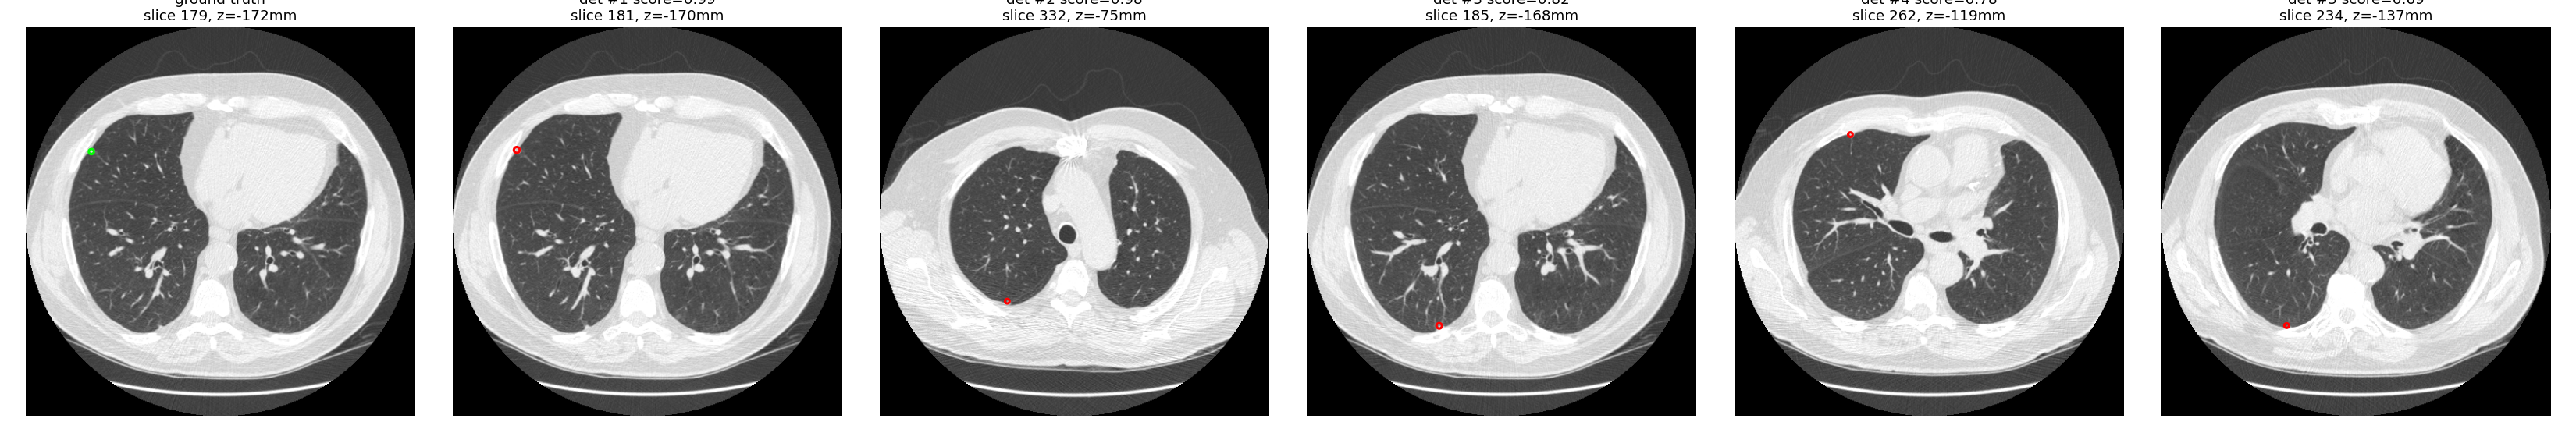

In [25]:
!python scripts/plot_lung_nodule_detections.py \
    --ct-dir /content/monai_scratch/lung_nodule_case/ct \
    --manifest /content/drive/MyDrive/doctor_assistant/monai_experts/results/monai_experts_manifest.json \
    --output-dir /content/drive/MyDrive/doctor_assistant/monai_experts/results \
    --top-n 5

# `!` shell commands don't stop notebook execution on failure -- without this check,
# a crashed plot script silently redisplays whatever stale PNG is already on Drive,
# which happened for real on this project (three re-runs in a row looked unchanged
# because the script was failing every time, not because the fix wasn't working).
assert _exit_code == 0, "plot script failed -- scroll up for the traceback, don't trust the image below"

from IPython.display import Image, display
display(Image('/content/drive/MyDrive/doctor_assistant/monai_experts/results/lung_nodule_detections_overlay.png'))


## Build OHIF-viewable bundles

Turns tonight's results into something you can actually open in the viewer, not just read as JSON. Each cell writes a ZIP to Drive containing the CT/MRI plus one or two DICOM SEG objects (AI result, and ground truth where available) as separate, independently-toggleable overlays -- the same bundle shape `scripts/publish_dicom_seg_to_orthanc.py` already knows how to upload.

**This step runs here in Colab. The actual publish step runs locally**, against your own Orthanc (`docs/DEVELOPMENT.md`'s CT section) -- download the ZIP from Drive, then on your own machine:
```
python scripts/publish_dicom_seg_to_orthanc.py --bundle <downloaded zip>
```
which prints the Clinique Amina OHIF URL to open.

The brain-tumour bundle wraps MSD's NIfTI-only data in a clearly-labeled **synthetic** DICOM container (fabricated IDs, real pixel data and real model output) -- see `scripts/nifti_to_dicom.py`'s docstring. The lung-nodule bundle uses the real DICOM CT directly; no synthesis needed there.

In [ ]:
!python scripts/build_lung_nodule_seg_bundle.py \
    --ct-dir /content/monai_scratch/lung_nodule_case/ct \
    --manifest /content/drive/MyDrive/doctor_assistant/monai_experts/results/monai_experts_manifest.json \
    --output-dir /content/drive/MyDrive/doctor_assistant/monai_experts/results \
    --top-n 5 --score-threshold 0.3
assert _exit_code == 0, "bundle script failed -- scroll up for the traceback"


In [ ]:
!python scripts/build_brain_tumor_seg_bundle.py \
    --data-dir /content/drive/MyDrive/doctor_assistant/monai_experts/data \
    --scratch-dir /content/monai_scratch \
    --output-dir /content/drive/MyDrive/doctor_assistant/monai_experts/results \
    --case-index 46
assert _exit_code == 0, "bundle script failed -- scroll up for the traceback"


In [26]:
import json
manifest = json.loads((OUTPUT / "monai_experts_manifest.json").read_text())
lung = next(r for r in manifest["results"] if r["expert"] == "lung_nodule")
print("ground truth:", lung["ground_truth"])
print()
for d in lung["detections"][:3]:
    print(d)
print()
print("match:", lung["match_at_threshold"])


ground truth: [{'center_lps_mm': [-123.89662954688767, -68.84402100666506, -171.87952809296007], 'diameter_mm': 4.977181063781087, 'supporting_readers': ['reader1', 'reader2', 'reader3', 'reader4'], 'reader_count': 4}]

{'center_lps_mm': [-125.61248779296875, -70.47085571289062, -170.4433135986328], 'size_whd_mm': [5.57208251953125, 5.61102294921875, 5.644378662109375], 'score': 0.9949955940246582}
{'center_lps_mm': [-63.799964904785156, 77.30438232421875, -75.20238494873047], 'size_whd_mm': [3.9383392333984375, 3.917572021484375, 3.8182830810546875], 'score': 0.9824556112289429}
{'center_lps_mm': [-59.18132781982422, 101.36212921142578, -167.771240234375], 'size_whd_mm': [5.0152130126953125, 5.0434112548828125, 5.3521575927734375], 'score': 0.8178418278694153}

match: {'score_threshold': 0.3, 'true_positives': 0, 'false_positives': 7, 'false_negatives': 1, 'ground_truth_count': 1, 'sensitivity': 0.0}


## What to do with the result

- **If Dice lands near 0.85 average** — the pipeline is real and the model performs as
  advertised on this data. That is the first genuine measured win in this project.
- **If it lands far below** — the preprocessing does not match what the bundle expects.
  That is a fixable bug, not a model failure; paste the output and we debug it.

Either way the honest headline is *"pipeline verified, indicative Dice X"* — not
*"our AI detects brain tumours at Dice X"*. The contamination status is why.

Next after this: resolve LUNA16 fold membership so the lung-nodule detector can be
scored, then render whichever expert works into Clinique Amina/OHIF.